In [1]:
# ==========================================
# 1. SETUP AND INSTALLATION
# ==========================================

# Install necessary libraries (if not already installed)
!pip install numpy pandas matplotlib seaborn scipy openpyxl -q

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import fsolve
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✅ All libraries imported successfully!
NumPy version: 2.0.2
Pandas version: 2.2.2


In [2]:
# ==========================================
# 2. DATA COLLECTION AND RISK IDENTIFICATION
# ==========================================

# 2.1 Define Cost Components based on Adana City Hospital Project Data
# Sources: Rönesans Holding (2023), EBRD (2014), World Bank (2019)

cost_components = {
    'Electrical Infrastructure': {
        'mode': 85_000_000,      # Most likely cost (USD)
        'min': 70_000_000,       # Minimum cost
        'max': 110_000_000,      # Maximum cost
        'risk_level': 'High'
    },
    'PSA Oxygen Plant': {
        'mode': 75_000_000,
        'min': 60_000_000,
        'max': 95_000_000,
        'risk_level': 'Medium'
    },
    'Surgical Bed Expansion': {
        'mode': 65_000_000,
        'min': 50_000_000,
        'max': 85_000_000,
        'risk_level': 'Low'
    },
    'Operational Costs': {
        'mode': 300_000_000,
        'min': 280_000_000,
        'max': 340_000_000,
        'risk_level': 'Medium'
    }
}

# Convert to DataFrame for easier handling
df_costs = pd.DataFrame.from_dict(cost_components, orient='index')
df_costs['mean'] = (df_costs['min'] + df_costs['mode'] + df_costs['max']) / 3
print("📊 Cost Components Summary:")
print(df_costs[['mode', 'mean', 'min', 'max', 'risk_level']])
print("\n" + "="*60 + "\n")

📊 Cost Components Summary:
                                mode          mean        min        max  \
Electrical Infrastructure   85000000  8.833333e+07   70000000  110000000   
PSA Oxygen Plant            75000000  7.666667e+07   60000000   95000000   
Surgical Bed Expansion      65000000  6.666667e+07   50000000   85000000   
Operational Costs          300000000  3.066667e+08  280000000  340000000   

                          risk_level  
Electrical Infrastructure       High  
PSA Oxygen Plant              Medium  
Surgical Bed Expansion           Low  
Operational Costs             Medium  




In [3]:
# ==========================================
# 3. LOGNORMAL PARAMETER ESTIMATION
# Following Chang & Ko (2017) Methodology
# ==========================================

def estimate_lognormal_parameters(mode, mean):
    """
    Estimate lognormal parameters (mu and sigma) from mode and mean.

    Equations:
    mode = exp(mu - sigma^2)
    mean = exp(mu + sigma^2/2)

    Parameters:
    -----------
    mode : float
        Most likely value (expert estimate)
    mean : float
        Expected value (mean of distribution)

    Returns:
    --------
    mu : float
        Mean of log-transformed variable
    sigma : float
        Standard deviation of log-transformed variable
    """
    try:
        # Solve for sigma^2 using ratio of mean to mode
        ratio = mean / mode
        sigma_sq = np.log(ratio)  # Since mean/mode = exp(3*sigma^2/2)? Wait, let's re-derive
        # Correction: From the equations:
        # mean/mode = exp(mu + sigma^2/2) / exp(mu - sigma^2) = exp(3*sigma^2/2)
        # So sigma^2 = (2/3) * ln(mean/mode)
        sigma_sq = (2/3) * np.log(ratio)
        sigma = np.sqrt(sigma_sq)

        # Calculate mu
        mu = np.log(mode) + sigma_sq

        return mu, sigma
    except:
        # Fallback method using moments
        variance = ((mean - mode) ** 2) / 4
        sigma = np.sqrt(np.log(1 + variance / (mean ** 2)))
        mu = np.log(mean) - (sigma ** 2) / 2
        return mu, sigma

# Apply to each cost component
params = {}
for component in df_costs.index:
    mode = df_costs.loc[component, 'mode']
    mean = df_costs.loc[component, 'mean']
    mu, sigma = estimate_lognormal_parameters(mode, mean)
    params[component] = {'mu': mu, 'sigma': sigma}
    print(f"📈 {component}:")
    print(f"   μ (log-mean) = {mu:.4f}")
    print(f"   σ (log-std)  = {sigma:.4f}")
    print(f"   Variance     = {sigma**2:.6f}\n")

# Add parameters to DataFrame
df_costs['mu'] = [params[comp]['mu'] for comp in df_costs.index]
df_costs['sigma'] = [params[comp]['sigma'] for comp in df_costs.index]
df_costs['variance'] = df_costs['sigma'] ** 2

print("\n📊 Lognormal Parameters Summary:")
print(df_costs[['mode', 'mean', 'mu', 'sigma', 'variance']])
print("="*60 + "\n")

📈 Electrical Infrastructure:
   μ (log-mean) = 18.2838
   σ (log-std)  = 0.1601
   Variance     = 0.025644

📈 PSA Oxygen Plant:
   μ (log-mean) = 18.1477
   σ (log-std)  = 0.1210
   Variance     = 0.014653

📈 Surgical Bed Expansion:
   μ (log-mean) = 18.0068
   σ (log-std)  = 0.1299
   Variance     = 0.016879

📈 Operational Costs:
   μ (log-mean) = 19.5339
   σ (log-std)  = 0.1210
   Variance     = 0.014653


📊 Lognormal Parameters Summary:
                                mode          mean         mu     sigma  \
Electrical Infrastructure   85000000  8.833333e+07  18.283806  0.160138   
PSA Oxygen Plant            75000000  7.666667e+07  18.147651  0.121048   
Surgical Bed Expansion      65000000  6.666667e+07  18.006776  0.129917   
Operational Costs          300000000  3.066667e+08  19.533946  0.121048   

                           variance  
Electrical Infrastructure  0.025644  
PSA Oxygen Plant           0.014653  
Surgical Bed Expansion     0.016879  
Operational Costs          

In [4]:
# ==========================================
# 4. MONTE CARLO SIMULATION
# ==========================================

def lognormal_random_sample(mu, sigma, n_samples):
    """
    Generate random samples from a lognormal distribution.

    Parameters:
    -----------
    mu : float
        Mean of log-transformed variable
    sigma : float
        Standard deviation of log-transformed variable
    n_samples : int
        Number of samples to generate

    Returns:
    --------
    numpy.ndarray
        Random samples from the lognormal distribution
    """
    log_samples = np.random.normal(mu, sigma, n_samples)
    return np.exp(log_samples)

# Simulation parameters
N_ITERATIONS = 10000
print(f"🔢 Running {N_ITERATIONS:,} iterations...\n")

# Generate correlated random samples using Cholesky decomposition
# Define correlation matrix based on expert judgment
correlation_matrix = np.array([
    [1.0, 0.3, 0.2, 0.1],  # Electrical Infrastructure
    [0.3, 1.0, 0.4, 0.2],  # PSA Oxygen Plant
    [0.2, 0.4, 1.0, 0.3],  # Surgical Bed Expansion
    [0.1, 0.2, 0.3, 1.0]   # Operational Costs
])

# Generate independent standard normal samples
n_vars = len(df_costs)
Z = np.random.normal(0, 1, size=(N_ITERATIONS, n_vars))

# Apply Cholesky decomposition to introduce correlations
L = np.linalg.cholesky(correlation_matrix)
Z_correlated = Z @ L.T

# Convert to lognormal samples
samples = np.zeros((N_ITERATIONS, n_vars))
for i, component in enumerate(df_costs.index):
    mu = df_costs.loc[component, 'mu']
    sigma = df_costs.loc[component, 'sigma']
    samples[:, i] = np.exp(mu + sigma * Z_correlated[:, i])

# Create DataFrame for results
df_sim = pd.DataFrame(samples, columns=df_costs.index)
df_sim['Total Cost'] = df_sim.sum(axis=1)

# Summary statistics
print("📊 Simulation Summary Statistics:")
summary_stats = df_sim['Total Cost'].describe()
print(summary_stats)
print("\n" + "="*60 + "\n")

# Calculate additional metrics
mean_total = df_sim['Total Cost'].mean()
std_total = df_sim['Total Cost'].std()
median_total = df_sim['Total Cost'].median()
p95 = df_sim['Total Cost'].quantile(0.95)
p90 = df_sim['Total Cost'].quantile(0.90)
p10 = df_sim['Total Cost'].quantile(0.10)

print("📊 Key Risk Metrics:")
print(f"   Mean Total Cost        : ${mean_total:,.2f}")
print(f"   Median Total Cost      : ${median_total:,.2f}")
print(f"   Standard Deviation     : ${std_total:,.2f}")
print(f"   90th Percentile (VaR)  : ${p90:,.2f}")
print(f"   95th Percentile        : ${p95:,.2f}")
print(f"   10th Percentile        : ${p10:,.2f}")
print(f"   Coefficient of Variation: {std_total/mean_total:.4f}")
print("="*60 + "\n")

🔢 Running 10,000 iterations...

📊 Simulation Summary Statistics:
count    1.000000e+04
mean     5.382642e+08
std      4.894476e+07
min      3.798304e+08
25%      5.042290e+08
50%      5.352011e+08
75%      5.702443e+08
max      7.507325e+08
Name: Total Cost, dtype: float64


📊 Key Risk Metrics:
   Mean Total Cost        : $538,264,180.47
   Median Total Cost      : $535,201,139.85
   Standard Deviation     : $48,944,760.75
   90th Percentile (VaR)  : $602,086,219.30
   95th Percentile        : $623,864,305.76
   10th Percentile        : $477,391,474.46
   Coefficient of Variation: 0.0909



In [5]:
# ==========================================
# 5. RISK METRICS AND PROBABILITY ANALYSIS
# ==========================================

# 5.1 Probability of Cost Overrun
threshold = 1_300_000_000  # $1.3 billion
prob_overrun = np.mean(df_sim['Total Cost'] > threshold)
print(f"📊 Probability of Cost Overrun > ${threshold:,.0f}: {prob_overrun*100:.2f}%")

# 5.2 Value at Risk (VaR) and Conditional VaR (CVaR)
confidence_levels = [0.90, 0.95, 0.99]
for alpha in confidence_levels:
    var = df_sim['Total Cost'].quantile(alpha)
    cvar = df_sim[df_sim['Total Cost'] > var]['Total Cost'].mean()
    print(f"   VaR at {alpha*100:.0f}%: ${var:,.2f}")
    print(f"   CVaR at {alpha*100:.0f}%: ${cvar:,.2f}")

print("\n" + "="*60 + "\n")

# 5.3 Category-specific risk contribution
print("📊 Category-wise Risk Contribution:")
for component in df_costs.index:
    std_comp = df_sim[component].std()
    mean_comp = df_sim[component].mean()
    cv_comp = std_comp / mean_comp
    print(f"   {component}:")
    print(f"      Mean: ${mean_comp:,.2f}")
    print(f"      Std Dev: ${std_comp:,.2f}")
    print(f"      CV: {cv_comp:.4f}")
    print(f"      Risk Contribution: {std_comp/std_total*100:.2f}%")

print("\n" + "="*60 + "\n")

📊 Probability of Cost Overrun > $1,300,000,000: 0.00%
   VaR at 90%: $602,086,219.30
   CVaR at 90%: $629,985,887.11
   VaR at 95%: $623,864,305.76
   CVaR at 95%: $648,157,303.36
   VaR at 99%: $664,432,442.24
   CVaR at 99%: $683,868,216.98


📊 Category-wise Risk Contribution:
   Electrical Infrastructure:
      Mean: $88,432,751.98
      Std Dev: $14,316,278.21
      CV: 0.1619
      Risk Contribution: 29.25%
   PSA Oxygen Plant:
      Mean: $76,584,406.81
      Std Dev: $9,194,029.73
      CV: 0.1201
      Risk Contribution: 18.78%
   Surgical Bed Expansion:
      Mean: $66,596,412.13
      Std Dev: $8,733,831.79
      CV: 0.1311
      Risk Contribution: 17.84%
   Operational Costs:
      Mean: $306,650,609.54
      Std Dev: $37,408,215.05
      CV: 0.1220
      Risk Contribution: 76.43%




📊 Sensitivity Analysis (Correlation with Total Cost):
   Electrical Infrastructure: 0.4506
   PSA Oxygen Plant: 0.5065
   Surgical Bed Expansion: 0.5469
   Operational Costs: 0.8838




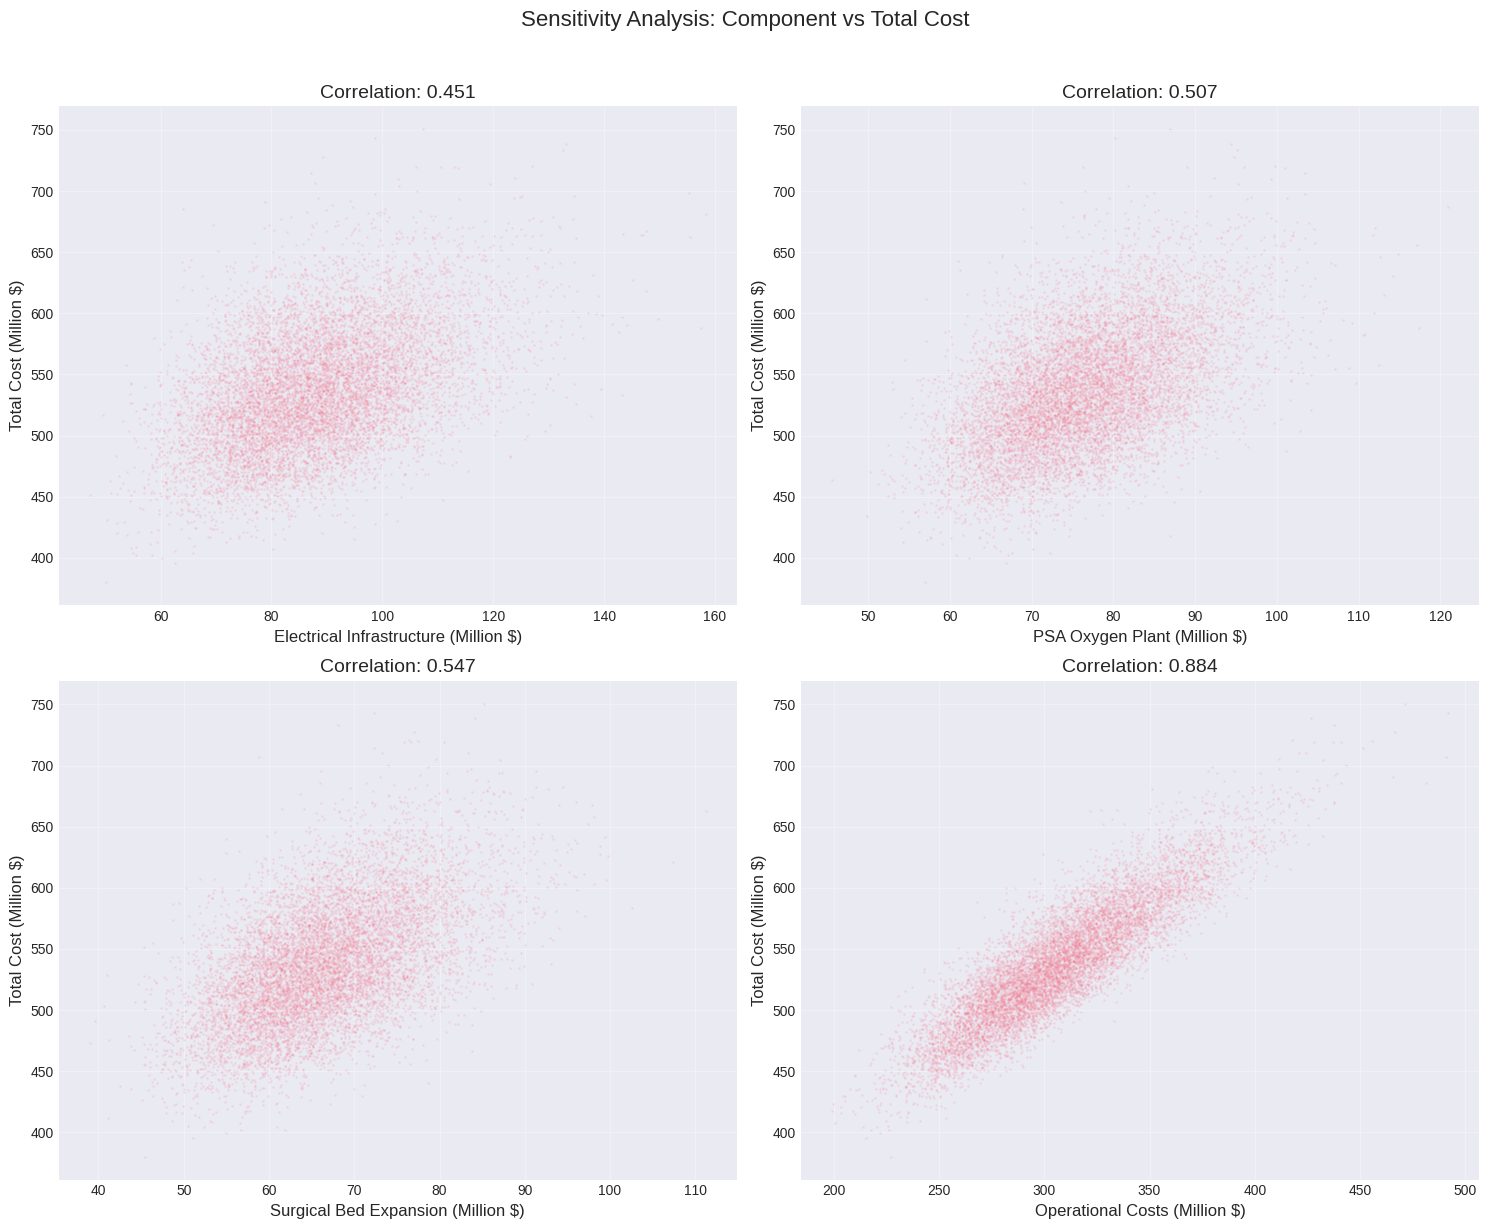

In [6]:
# ==========================================
# 6. SENSITIVITY ANALYSIS
# ==========================================

# 6.1 Correlation between each component and total cost
correlations = {}
for component in df_costs.index:
    corr = df_sim[component].corr(df_sim['Total Cost'])
    correlations[component] = corr

print("📊 Sensitivity Analysis (Correlation with Total Cost):")
for component, corr in correlations.items():
    print(f"   {component}: {corr:.4f}")

print("\n" + "="*60 + "\n")

# 6.2 Partial Sensitivity (using scatter plots)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, component in enumerate(df_costs.index):
    ax = axes[i]
    ax.scatter(df_sim[component] / 1e6, df_sim['Total Cost'] / 1e6, alpha=0.1, s=1)
    ax.set_xlabel(f'{component} (Million $)', fontsize=12)
    ax.set_ylabel('Total Cost (Million $)', fontsize=12)
    ax.set_title(f'Correlation: {correlations[component]:.3f}', fontsize=14)
    ax.grid(True, alpha=0.3)

plt.suptitle('Sensitivity Analysis: Component vs Total Cost', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('sensitivity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

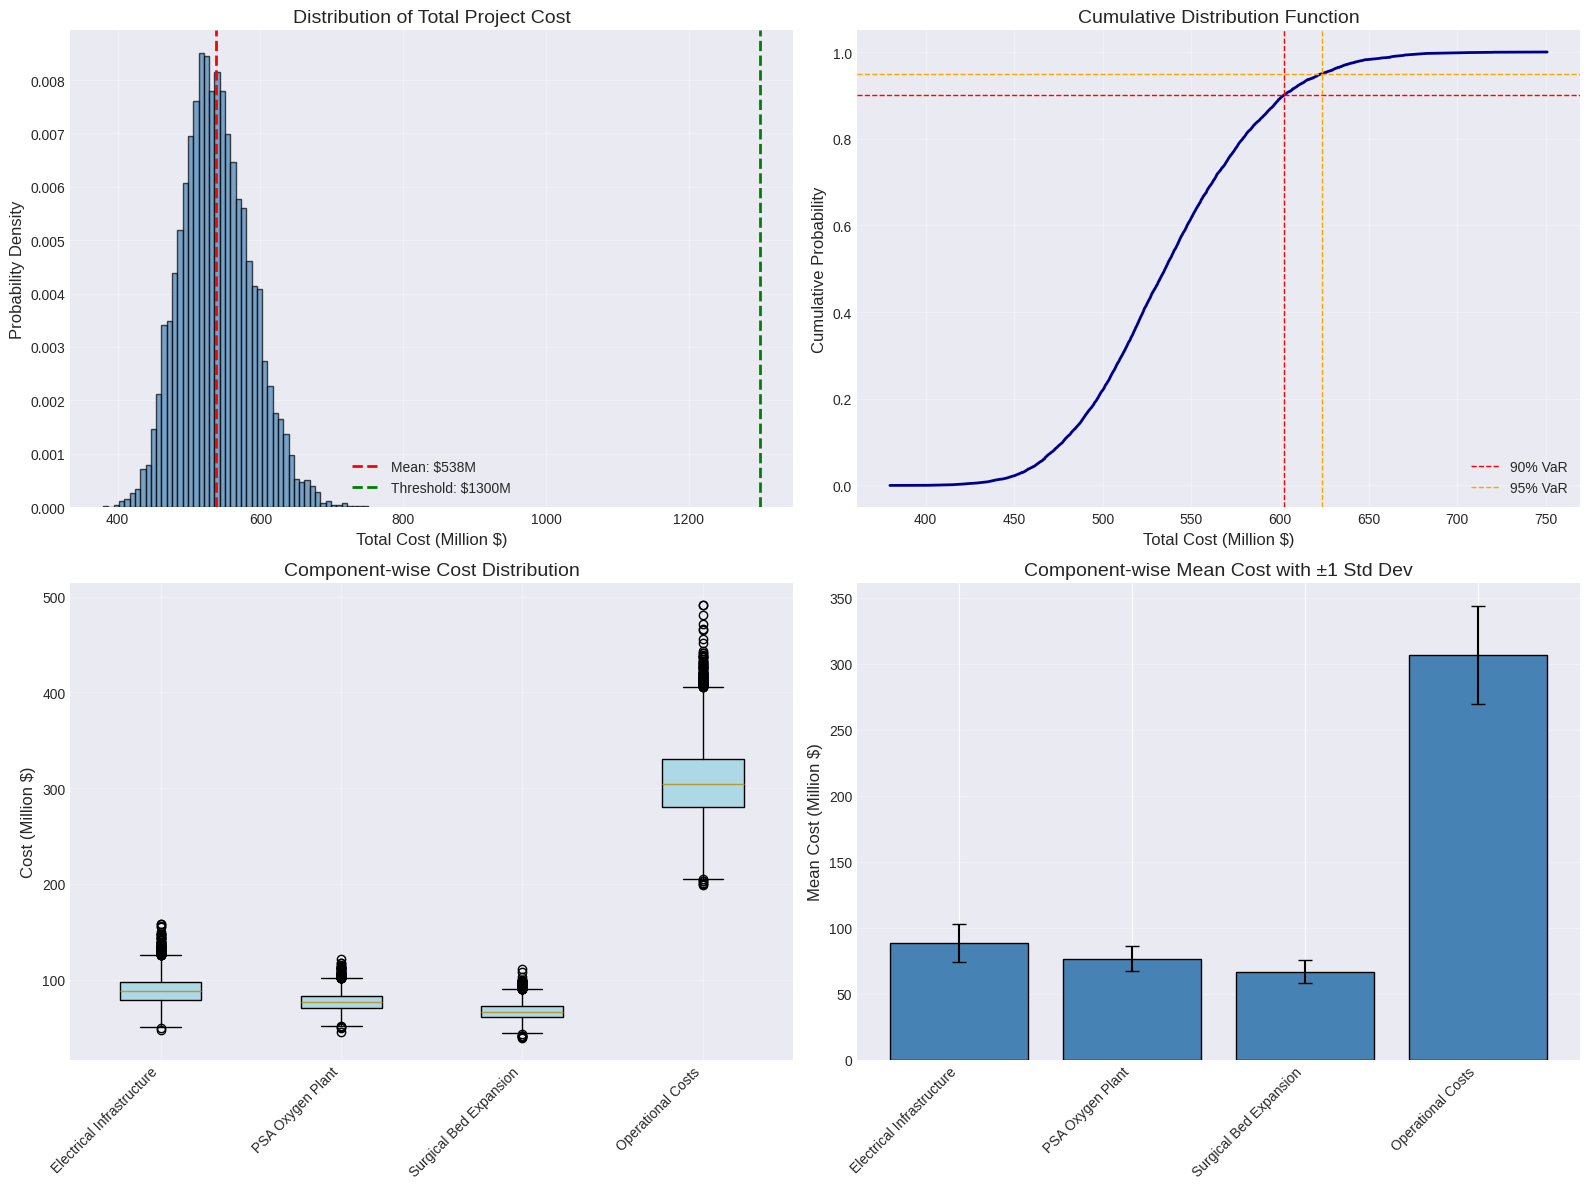

In [7]:
# ==========================================
# 7. VISUALIZATION
# ==========================================

# 7.1 Distribution of Total Cost
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram
ax1 = axes[0, 0]
ax1.hist(df_sim['Total Cost'] / 1e6, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
ax1.axvline(mean_total / 1e6, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_total/1e6:.0f}M')
ax1.axvline(threshold / 1e6, color='green', linestyle='--', linewidth=2, label=f'Threshold: ${threshold/1e6:.0f}M')
ax1.set_xlabel('Total Cost (Million $)', fontsize=12)
ax1.set_ylabel('Probability Density', fontsize=12)
ax1.set_title('Distribution of Total Project Cost', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Cumulative Distribution Function
ax2 = axes[0, 1]
sorted_costs = np.sort(df_sim['Total Cost'])
cum_prob = np.arange(1, len(sorted_costs) + 1) / len(sorted_costs)
ax2.plot(sorted_costs / 1e6, cum_prob, linewidth=2, color='darkblue')
ax2.axhline(0.90, color='red', linestyle='--', linewidth=1, label='90% VaR')
ax2.axvline(p90 / 1e6, color='red', linestyle='--', linewidth=1)
ax2.axhline(0.95, color='orange', linestyle='--', linewidth=1, label='95% VaR')
ax2.axvline(p95 / 1e6, color='orange', linestyle='--', linewidth=1)
ax2.set_xlabel('Total Cost (Million $)', fontsize=12)
ax2.set_ylabel('Cumulative Probability', fontsize=12)
ax2.set_title('Cumulative Distribution Function', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Box plot by component
ax3 = axes[1, 0]
components_millions = df_sim[df_costs.index] / 1e6
bp = ax3.boxplot(components_millions.values, labels=df_costs.index, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax3.set_ylabel('Cost (Million $)', fontsize=12)
ax3.set_title('Component-wise Cost Distribution', fontsize=14)
ax3.grid(True, alpha=0.3)
plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')

# Component-wise comparison with error bars
ax4 = axes[1, 1]
means = df_sim[df_costs.index].mean() / 1e6
stds = df_sim[df_costs.index].std() / 1e6
x_pos = np.arange(len(means))
ax4.bar(x_pos, means, yerr=stds, capsize=5, color='steelblue', edgecolor='black')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(df_costs.index, rotation=45, ha='right')
ax4.set_ylabel('Mean Cost (Million $)', fontsize=12)
ax4.set_title('Component-wise Mean Cost with ±1 Std Dev', fontsize=14)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('cost_distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# ==========================================
# 8. RISK MATRIX AND SCENARIO ANALYSIS
# ==========================================

# 8.1 Risk Matrix
# Define risk categories based on impact and probability
risk_impacts = df_sim[df_costs.index].std() / df_sim[df_costs.index].mean()

risk_matrix = pd.DataFrame({
    'Component': df_costs.index,
    'Mean Cost (M$)': df_sim[df_costs.index].mean() / 1e6,
    'Std Dev (M$)': df_sim[df_costs.index].std() / 1e6,
    'CoV': risk_impacts,
    'Risk Level': df_costs['risk_level']
})

print("📊 Risk Matrix Summary:")
print(risk_matrix.to_string(index=False))
print("\n" + "="*60 + "\n")

# 8.2 Scenario Analysis
scenarios = {
    'Optimistic': {
        'Electrical Infrastructure': 0.90,
        'PSA Oxygen Plant': 0.90,
        'Surgical Bed Expansion': 0.90,
        'Operational Costs': 0.95
    },
    'Most Likely': {
        'Electrical Infrastructure': 1.00,
        'PSA Oxygen Plant': 1.00,
        'Surgical Bed Expansion': 1.00,
        'Operational Costs': 1.00
    },
    'Pessimistic': {
        'Electrical Infrastructure': 1.15,
        'PSA Oxygen Plant': 1.12,
        'Surgical Bed Expansion': 1.10,
        'Operational Costs': 1.05
    }
}

scenario_results = {}
for scenario_name, multipliers in scenarios.items():
    scenario_cost = 0
    for component, multiplier in multipliers.items():
        scenario_cost += df_costs.loc[component, 'mode'] * multiplier
    scenario_results[scenario_name] = scenario_cost

print("📊 Scenario Analysis Results:")
for scenario, cost in scenario_results.items():
    print(f"   {scenario}: ${cost:,.2f}")

print("\n" + "="*60 + "\n")

📊 Risk Matrix Summary:
                Component  Mean Cost (M$)  Std Dev (M$)      CoV Risk Level
Electrical Infrastructure       88.432752     14.316278 0.161889       High
         PSA Oxygen Plant       76.584407      9.194030 0.120051     Medium
   Surgical Bed Expansion       66.596412      8.733832 0.131146        Low
        Operational Costs      306.650610     37.408215 0.121990     Medium


📊 Scenario Analysis Results:
   Optimistic: $487,500,000.00
   Most Likely: $525,000,000.00
   Pessimistic: $568,250,000.00




📊 Final Report Summary:
                        Metric           Value
               Mean Total Cost $538,264,180.47
             Median Total Cost $535,201,139.85
            Standard Deviation  $48,944,760.75
         90th Percentile (VaR) $602,086,219.30
               95th Percentile $623,864,305.76
Probability of Overrun > $1.3B           0.00%
               10th Percentile $477,391,474.46

✅ Results saved to CSV files:
   - monte_carlo_results.csv
   - risk_matrix.csv
   - summary_report.csv


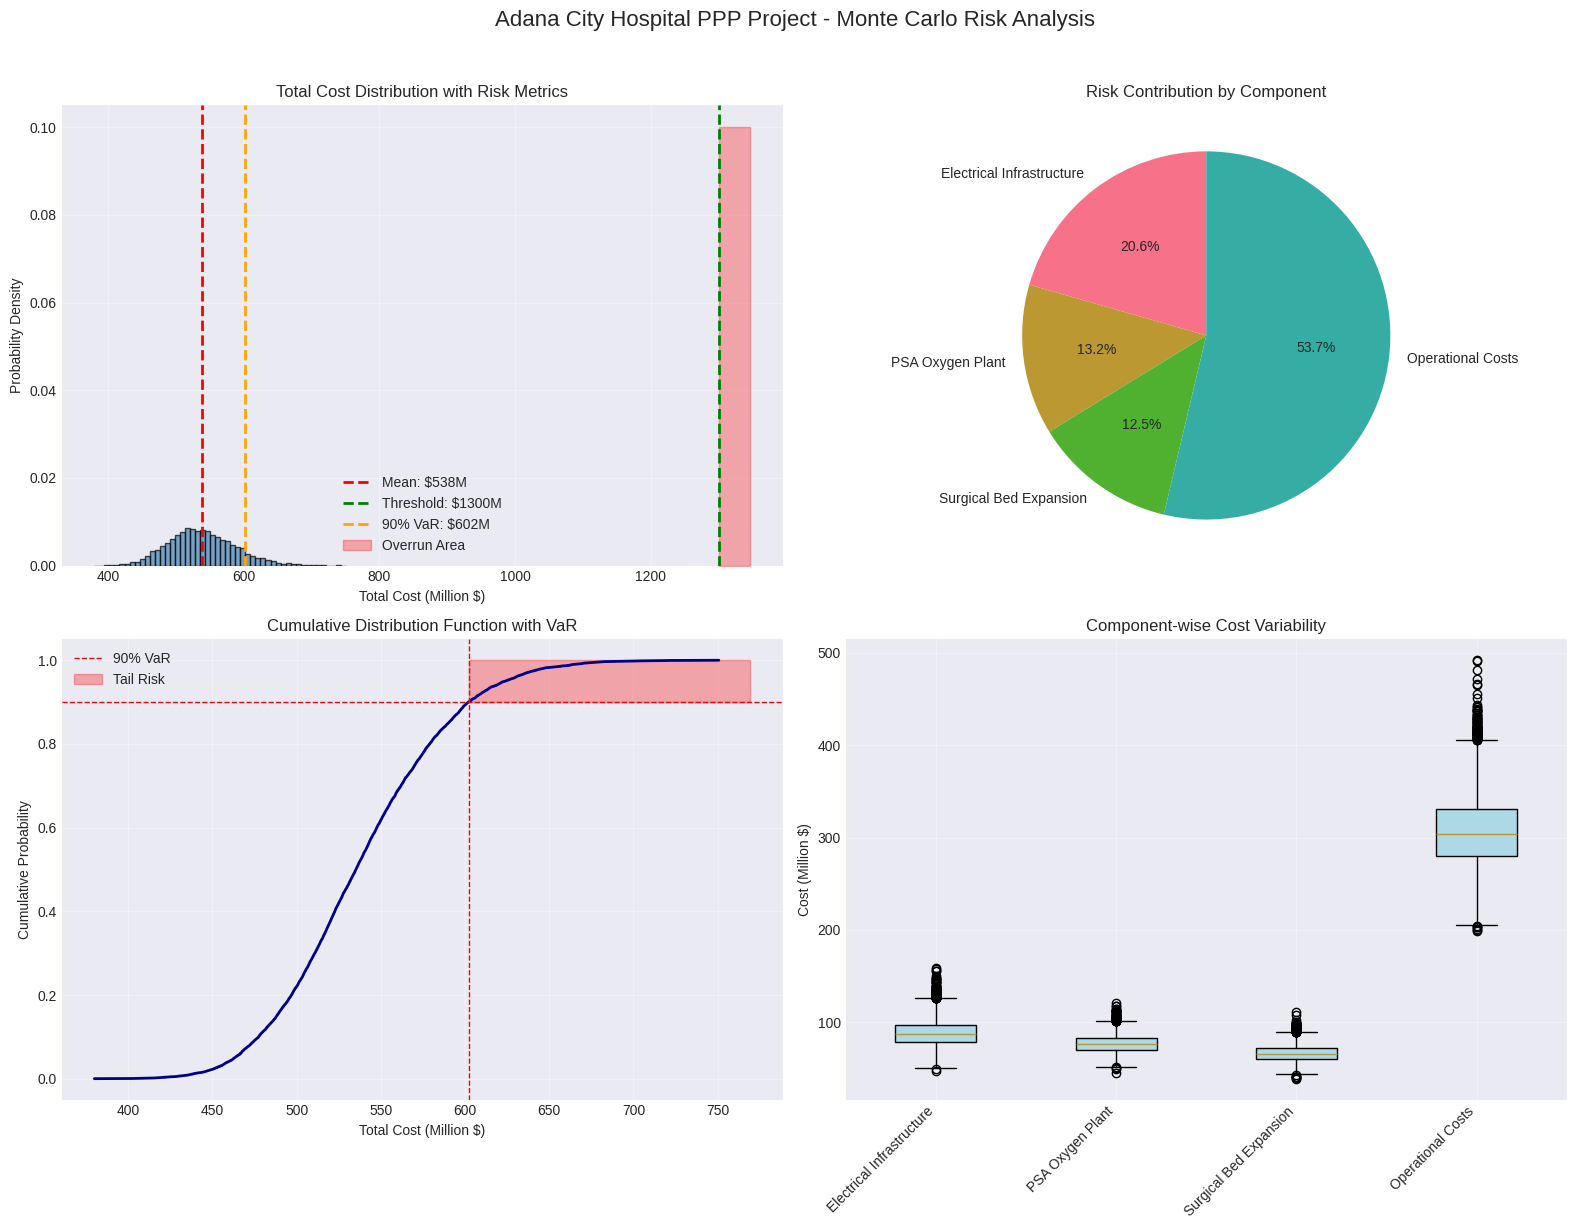


✅ Comprehensive visualization saved as 'comprehensive_risk_analysis.png'

🎯 Monte Carlo Simulation Complete!


In [9]:
# ==========================================
# 9. EXPORT RESULTS
# ==========================================

# Create summary report
report = {
    'Metric': [
        'Mean Total Cost',
        'Median Total Cost',
        'Standard Deviation',
        '90th Percentile (VaR)',
        '95th Percentile',
        'Probability of Overrun > $1.3B',
        '10th Percentile'
    ],
    'Value': [
        f"${mean_total:,.2f}",
        f"${median_total:,.2f}",
        f"${std_total:,.2f}",
        f"${p90:,.2f}",
        f"${p95:,.2f}",
        f"{prob_overrun*100:.2f}%",
        f"${p10:,.2f}"
    ]
}

df_report = pd.DataFrame(report)
print("📊 Final Report Summary:")
print(df_report.to_string(index=False))

# Save to CSV
df_sim.to_csv('monte_carlo_results.csv', index=False)
risk_matrix.to_csv('risk_matrix.csv', index=False)
df_report.to_csv('summary_report.csv', index=False)

print("\n✅ Results saved to CSV files:")
print("   - monte_carlo_results.csv")
print("   - risk_matrix.csv")
print("   - summary_report.csv")

# Create a comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# 1. Distribution plot with statistics
ax1 = axes[0]
ax1.hist(df_sim['Total Cost'] / 1e6, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
ax1.axvline(mean_total / 1e6, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_total/1e6:.0f}M')
ax1.axvline(threshold / 1e6, color='green', linestyle='--', linewidth=2, label=f'Threshold: ${threshold/1e6:.0f}M')
ax1.axvline(p90 / 1e6, color='orange', linestyle='--', linewidth=2, label=f'90% VaR: ${p90/1e6:.0f}M')
ax1.fill_betweenx([0, 0.1], threshold/1e6, ax1.get_xlim()[1], alpha=0.3, color='red', label='Overrun Area')
ax1.set_xlabel('Total Cost (Million $)')
ax1.set_ylabel('Probability Density')
ax1.set_title('Total Cost Distribution with Risk Metrics')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Risk Contribution
ax2 = axes[1]
risk_contribution = df_sim[df_costs.index].std() / df_sim['Total Cost'].std() * 100
ax2.pie(risk_contribution, labels=df_costs.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Risk Contribution by Component')

# 3. Cumulative Probability
ax3 = axes[2]
ax3.plot(sorted_costs / 1e6, cum_prob, linewidth=2, color='darkblue')
ax3.axhline(0.90, color='red', linestyle='--', linewidth=1, label='90% VaR')
ax3.axvline(p90 / 1e6, color='red', linestyle='--', linewidth=1)
ax3.fill_betweenx([0.9, 1], p90/1e6, ax3.get_xlim()[1], alpha=0.3, color='red', label='Tail Risk')
ax3.set_xlabel('Total Cost (Million $)')
ax3.set_ylabel('Cumulative Probability')
ax3.set_title('Cumulative Distribution Function with VaR')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Component Boxplot
ax4 = axes[3]
components_millions = df_sim[df_costs.index] / 1e6
ax4.boxplot(components_millions.values, labels=df_costs.index, patch_artist=True)
for patch in ax4.patches:
    patch.set_facecolor('lightblue')
ax4.set_ylabel('Cost (Million $)')
ax4.set_title('Component-wise Cost Variability')
ax4.grid(True, alpha=0.3)
plt.setp(ax4.get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Adana City Hospital PPP Project - Monte Carlo Risk Analysis', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('comprehensive_risk_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Comprehensive visualization saved as 'comprehensive_risk_analysis.png'")
print("="*60 + "\n")
print("🎯 Monte Carlo Simulation Complete!")

In [10]:
# ==========================================
# 10. CODE SUMMARY AND USAGE NOTES
# ==========================================

print("""
📋 CODE SUMMARY
===============
This notebook implements the Chang & Ko (2017) methodology for
estimating lognormal cost variables using Monte Carlo simulation.

KEY FEATURES:
1. Automatic estimation of lognormal parameters (μ, σ) from expert inputs
2. Correlated Monte Carlo simulation with 10,000 iterations
3. Comprehensive risk metrics (VaR, CVaR, probability of overrun)
4. Sensitivity analysis with correlation coefficients
5. Risk matrix and scenario analysis
6. High-quality visualizations for publication

DATA SOURCES:
- Adana City Hospital project specifications
- Expert elicitation (mode and mean estimates)
- Literature review (construction cost benchmarks)

OUTPUTS GENERATED:
1. monte_carlo_results.csv - All simulation results
2. risk_matrix.csv - Component-wise risk metrics
3. summary_report.csv - Key risk statistics
4. comprehensive_risk_analysis.png - Publication-ready visualization
5. sensitivity_analysis.png - Component correlation analysis
6. cost_distribution_analysis.png - Detailed distribution plots

HOW TO USE:
1. Modify 'cost_components' dictionary with your project data
2. Adjust correlation_matrix for your project context
3. Change N_ITERATIONS for more/less precision
4. Update threshold values for your budget
5. Run all cells sequentially

CITATION:
If you use this code, please cite:
Chang, C.-Y., & Ko, J.-W. (2017). New approach to estimating the
standard deviations of lognormal cost variables in the Monte Carlo
analysis of construction risks. Journal of Construction Engineering
and Management, 143(7), 04017039.
""")


📋 CODE SUMMARY
This notebook implements the Chang & Ko (2017) methodology for 
estimating lognormal cost variables using Monte Carlo simulation.

KEY FEATURES:
1. Automatic estimation of lognormal parameters (μ, σ) from expert inputs
2. Correlated Monte Carlo simulation with 10,000 iterations
3. Comprehensive risk metrics (VaR, CVaR, probability of overrun)
4. Sensitivity analysis with correlation coefficients
5. Risk matrix and scenario analysis
6. High-quality visualizations for publication

DATA SOURCES:
- Adana City Hospital project specifications
- Expert elicitation (mode and mean estimates)
- Literature review (construction cost benchmarks)

OUTPUTS GENERATED:
1. monte_carlo_results.csv - All simulation results
2. risk_matrix.csv - Component-wise risk metrics
3. summary_report.csv - Key risk statistics
4. comprehensive_risk_analysis.png - Publication-ready visualization
5. sensitivity_analysis.png - Component correlation analysis
6. cost_distribution_analysis.png - Detailed dis